# Task 3 — CLIP

## Setup

In [1]:
# Colab setup. If running locally and these are already installed, skip this cell.
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
import json
import random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import clip
from torchvision.datasets import STL10
from torch.utils.data import DataLoader, Subset

# Reproducibility. CLIP inference is deterministic, but t-SNE/UMAP and the
# subset sampling below are not, so the seed matters for the figures.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM: %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1e9))

DATA_ROOT = "./data"
FIG_DIR = "./figures"
CACHE_DIR = "./cache"
for d in (FIG_DIR, CACHE_DIR):
    os.makedirs(d, exist_ok=True)

# Batch size: large on GPU, conservative on CPU / small-VRAM cards.
BATCH_SIZE = 256 if DEVICE == "cuda" else 32
NUM_WORKERS = 2
print("Batch size:", BATCH_SIZE)

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Batch size: 256


### Optional: Persist to Google Drive

In [3]:
# Set to True on Colab to keep the STL-10 download, the cached CLIP features,
# the figures and the results JSON across sessions. Colab wipes local storage
# when the runtime disconnects, and torchvision re-downloads the full 2.5 GB
# STL-10 archive from scratch every time otherwise.
#
# Run this cell AFTER the imports cell — it overrides the paths defined there.
USE_DRIVE = False

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    BASE = "/content/drive/MyDrive/atml_assignment0/task3"
    DATA_ROOT = os.path.join(BASE, "data")
    FIG_DIR = os.path.join(BASE, "figures")
    CACHE_DIR = os.path.join(BASE, "cache")
    RESULTS_PATH = os.path.join(BASE, "task3_results.json")
    for d in (DATA_ROOT, FIG_DIR, CACHE_DIR):
        os.makedirs(d, exist_ok=True)
else:
    RESULTS_PATH = "task3_results.json"

print("DATA_ROOT   ", DATA_ROOT)
print("CACHE_DIR   ", CACHE_DIR)
print("FIG_DIR     ", FIG_DIR)
print("RESULTS_PATH", RESULTS_PATH)

DATA_ROOT    ./data
CACHE_DIR    ./cache
FIG_DIR      ./figures
RESULTS_PATH task3_results.json


## 3.1 Zero-Shot Classification on STL-10

### Load CLIP

In [4]:
MODEL_NAME = "ViT-B/32"

model, preprocess = clip.load(MODEL_NAME, device=DEVICE)
model.eval()  # no dropout, no batchnorm updates — we only ever do inference

n_params = sum(p.numel() for p in model.parameters())
print("Model:", MODEL_NAME)
print("Parameters: %.1fM" % (n_params / 1e6))
print("\nPreprocessing pipeline supplied by CLIP:")
print(preprocess)

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 102MiB/s]


Model: ViT-B/32
Parameters: 151.3M

Preprocessing pipeline supplied by CLIP:
Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7fb3da76a480>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


### Load STL-10

In [5]:
# The STL-10 test split has 8,000 labelled images across 10 classes (800 each).
# The train split has 5,000 labelled images — we use it later to fit Procrustes,
# so that the alignment is never fitted on the data we evaluate on.
test_set = STL10(root=DATA_ROOT, split="test", download=True, transform=preprocess)
train_set = STL10(root=DATA_ROOT, split="train", download=True, transform=preprocess)

CLASSES = list(test_set.classes)
print("Test images: ", len(test_set))
print("Train images:", len(train_set))
print("Classes:", CLASSES)

# Sanity check: torchvision's label order must match the order we build prompts in.
assert CLASSES == ["airplane", "bird", "car", "cat", "deer",
                   "dog", "horse", "monkey", "ship", "truck"]

100%|██████████| 2.64G/2.64G [03:26<00:00, 12.8MB/s]


Test images:  8000
Train images: 5000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


### Encode Images

In [6]:
@torch.no_grad()
def encode_images(dataset, desc="encoding"):
    """Run every image through CLIP's vision encoder once.

    Returns raw (un-normalised) float32 features on the CPU, plus labels.
    We deliberately keep them un-normalised: Part 2 asks whether L2
    normalisation affects the modality gap, so we need both versions.
    """
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))
    feats, labels = [], []
    for images, ys in tqdm(loader, desc=desc):
        images = images.to(DEVICE, non_blocking=True)
        f = model.encode_image(images)      # (B, 512), fp16 on GPU
        feats.append(f.float().cpu())       # cast to fp32 before caching
        labels.append(ys)
    return torch.cat(feats), torch.cat(labels)


CACHE_PATH = os.path.join(CACHE_DIR, "stl10_%s.pt" % MODEL_NAME.replace("/", "-"))

if os.path.exists(CACHE_PATH):
    blob = torch.load(CACHE_PATH)
    test_feats, test_labels = blob["test_feats"], blob["test_labels"]
    train_feats, train_labels = blob["train_feats"], blob["train_labels"]
    print("Loaded cached features from", CACHE_PATH)
else:
    test_feats, test_labels = encode_images(test_set, "test images")
    train_feats, train_labels = encode_images(train_set, "train images")
    torch.save({"test_feats": test_feats, "test_labels": test_labels,
                "train_feats": train_feats, "train_labels": train_labels},
               CACHE_PATH)
    print("Cached features to", CACHE_PATH)

print("Test features: ", tuple(test_feats.shape))
print("Train features:", tuple(train_feats.shape))
print("Embedding dim: ", test_feats.shape[1])

test images:   0%|          | 0/32 [00:00<?, ?it/s]

train images:   0%|          | 0/20 [00:00<?, ?it/s]

Cached features to ./cache/stl10_ViT-B-32.pt
Test features:  (8000, 512)
Train features: (5000, 512)
Embedding dim:  512


### Prompting Strategies

In [7]:
# --- Strategy A: plain labels -------------------------------------------------
def prompts_plain(classes):
    return [c for c in classes]

# --- Strategy B: standard "a photo of a {}" template --------------------------
def prompts_photo(classes):
    return ["a photo of a %s." % c for c in classes]

# --- Strategy C: hand-written descriptive prompts -----------------------------
DESCRIPTIVE = {
    "airplane": "a photo of an airplane, a fixed-wing aircraft flying in the sky.",
    "bird":     "a photo of a bird, a small feathered animal with wings and a beak.",
    "car":      "a photo of a car, a four-wheeled passenger automobile on a road.",
    "cat":      "a photo of a cat, a small domestic feline with whiskers and pointed ears.",
    "deer":     "a photo of a deer, a wild hoofed animal with antlers standing in a forest.",
    "dog":      "a photo of a dog, a domestic canine pet with fur and a wagging tail.",
    "horse":    "a photo of a horse, a large hoofed animal with a mane, often in a field.",
    "monkey":   "a photo of a monkey, a primate with long limbs and a long tail.",
    "ship":     "a photo of a ship, a large boat sailing on the open ocean.",
    "truck":    "a photo of a truck, a large heavy vehicle for transporting cargo.",
}

def prompts_descriptive(classes):
    return [DESCRIPTIVE[c] for c in classes]

# --- Strategy D: prompt ensemble ----------------------------------------------
ENSEMBLE_TEMPLATES = [
    "a photo of a {}.",
    "a blurry photo of a {}.",
    "a low resolution photo of a {}.",
    "a close-up photo of a {}.",
    "a bright photo of a {}.",
    "a photo of one {}.",
    "a photo of a small {}.",
]

for name, fn in [("A. plain", prompts_plain),
                 ("B. photo", prompts_photo),
                 ("C. descriptive", prompts_descriptive)]:
    print("%-16s -> %s" % (name, fn(CLASSES)[3]))
print("%-16s -> %d templates x %d classes" % ("D. ensemble",
                                              len(ENSEMBLE_TEMPLATES), len(CLASSES)))

A. plain         -> cat
B. photo         -> a photo of a cat.
C. descriptive   -> a photo of a cat, a small domestic feline with whiskers and pointed ears.
D. ensemble      -> 7 templates x 10 classes


In [8]:
@torch.no_grad()
def encode_text(prompts):
    """Tokenise and encode a list of prompt strings. Returns raw fp32 features."""
    tokens = clip.tokenize(prompts).to(DEVICE)
    feats = model.encode_text(tokens)
    return feats.float().cpu()


@torch.no_grad()
def encode_text_ensemble(classes, templates):
    """One vector per class: mean of L2-normalised template embeddings.

    Normalising *before* averaging matters. Raw CLIP features vary in magnitude,
    so a plain mean would let longer/higher-norm templates dominate the average.
    """
    out = []
    for c in classes:
        feats = encode_text([t.format(c) for t in templates])
        feats = F.normalize(feats, dim=-1)
        out.append(F.normalize(feats.mean(dim=0), dim=-1))
    return torch.stack(out)


text_features = {
    "A. plain label":      encode_text(prompts_plain(CLASSES)),
    "B. photo prompt":     encode_text(prompts_photo(CLASSES)),
    "C. descriptive":      encode_text(prompts_descriptive(CLASSES)),
    "D. prompt ensemble":  encode_text_ensemble(CLASSES, ENSEMBLE_TEMPLATES),
}

for k, v in text_features.items():
    print("%-20s %s" % (k, tuple(v.shape)))

A. plain label       (10, 512)
B. photo prompt      (10, 512)
C. descriptive       (10, 512)
D. prompt ensemble   (10, 512)


### Zero-Shot Evaluation

In [9]:
def zero_shot_predict(image_features, class_text_features):
    """Cosine-similarity classification. Returns (predictions, similarity matrix)."""
    img = F.normalize(image_features, dim=-1)     # (N, 512)
    txt = F.normalize(class_text_features, dim=-1) # (10, 512)
    sims = img @ txt.T                             # (N, 10)
    return sims.argmax(dim=-1), sims


def top1_accuracy(preds, labels):
    return (preds == labels).float().mean().item()


results = {}
predictions = {}

print("Zero-shot top-1 accuracy on the full STL-10 test set (%d images)\n" % len(test_labels))
print("%-22s %s" % ("Strategy", "Top-1"))
print("-" * 32)
for name, txt in text_features.items():
    preds, _ = zero_shot_predict(test_feats, txt)
    acc = top1_accuracy(preds, test_labels)
    results[name] = acc
    predictions[name] = preds
    print("%-22s %6.2f%%" % (name, 100 * acc))

best_strategy = max(results, key=results.get)
print("\nBest strategy: %s (%.2f%%)" % (best_strategy, 100 * results[best_strategy]))

Zero-shot top-1 accuracy on the full STL-10 test set (8000 images)

Strategy               Top-1
--------------------------------
A. plain label          96.25%
B. photo prompt         97.31%
C. descriptive          92.76%
D. prompt ensemble      96.86%

Best strategy: B. photo prompt (97.31%)


### Per-Class Accuracy and Confusion Matrix

Per-class accuracy (B. photo prompt)

  airplane    98.25%
  bird        99.75%
  car         96.75%
  cat         89.25%
  deer        97.25%
  dog         97.12%
  horse       99.12%
  monkey      96.88%
  ship        99.87%
  truck       98.87%


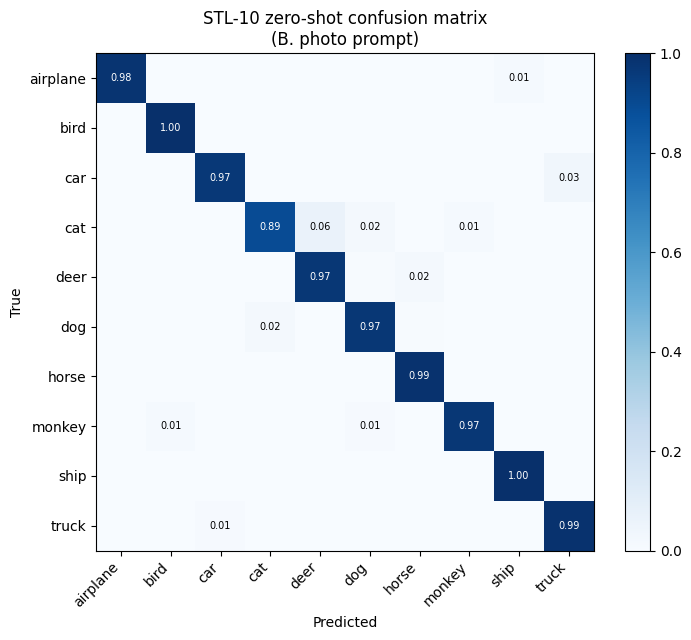


Top confusions (true -> predicted):
  cat        -> deer         51 images
  car        -> truck        26 images
  cat        -> dog          18 images
  dog        -> cat          14 images
  deer       -> horse        14 images


In [10]:
best_preds = predictions[best_strategy]

# Per-class accuracy
print("Per-class accuracy (%s)\n" % best_strategy)
per_class = {}
for i, c in enumerate(CLASSES):
    mask = test_labels == i
    acc = (best_preds[mask] == test_labels[mask]).float().mean().item()
    per_class[c] = acc
    print("  %-10s %6.2f%%" % (c, 100 * acc))

# Confusion matrix
cm = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
for t, p in zip(test_labels.numpy(), best_preds.numpy()):
    cm[t, p] += 1
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("STL-10 zero-shot confusion matrix\n(%s)" % best_strategy)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if cm_norm[i, j] > 0.01:
            ax.text(j, i, "%.2f" % cm_norm[i, j], ha="center", va="center",
                    fontsize=7, color="white" if cm_norm[i, j] > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "confusion_matrix.png"), dpi=200)
plt.show()

# Most common confusions, useful to quote in the report
off = [(cm[i, j], CLASSES[i], CLASSES[j])
       for i in range(len(CLASSES)) for j in range(len(CLASSES)) if i != j]
off.sort(reverse=True)
print("\nTop confusions (true -> predicted):")
for n, t, p in off[:5]:
    print("  %-10s -> %-10s %4d images" % (t, p, n))

### Sample Predictions

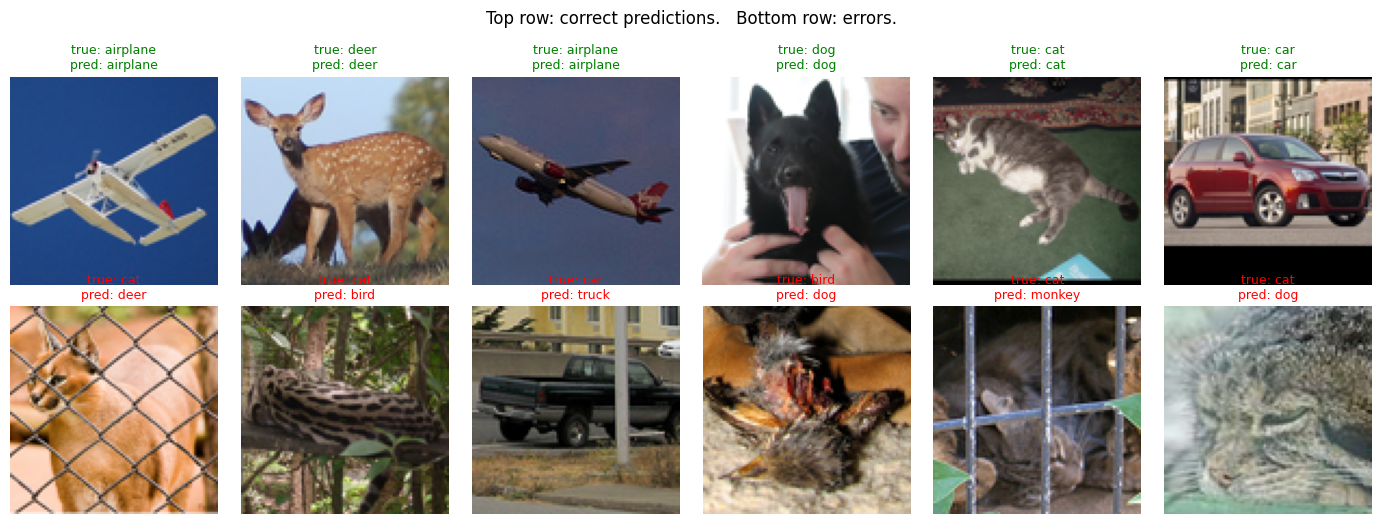

In [11]:
# Reload the test set without CLIP's normalisation so images are displayable.
from torchvision import transforms
display_set = STL10(root=DATA_ROOT, split="test", download=False,
                    transform=transforms.ToTensor())

correct_idx = torch.where(best_preds == test_labels)[0]
wrong_idx = torch.where(best_preds != test_labels)[0]
g = torch.Generator().manual_seed(SEED)
show = torch.cat([
    correct_idx[torch.randperm(len(correct_idx), generator=g)[:6]],
    wrong_idx[torch.randperm(len(wrong_idx), generator=g)[:6]],
])

fig, axes = plt.subplots(2, 6, figsize=(14, 5.2))
for ax, idx in zip(axes.flat, show.tolist()):
    img, y = display_set[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.axis("off")
    p = best_preds[idx].item()
    ok = (p == y)
    ax.set_title("true: %s\npred: %s" % (CLASSES[y], CLASSES[p]),
                 fontsize=9, color=("green" if ok else "red"))
fig.suptitle("Top row: correct predictions.   Bottom row: errors.", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "sample_predictions.png"), dpi=200)
plt.show()

## 3.2 Exploring the Modality Gap

### Extract Embeddings

In [12]:
N_PER_CLASS = 10   # 10 classes x 10 = 100 samples, per the assignment's 50-100 range

sample_idx = []
for c in range(len(CLASSES)):
    idx = torch.where(test_labels == c)[0]
    perm = torch.randperm(len(idx), generator=torch.Generator().manual_seed(SEED))
    sample_idx.append(idx[perm[:N_PER_CLASS]])
sample_idx = torch.cat(sample_idx)

sample_img_feats = test_feats[sample_idx]        # (100, 512) raw
sample_labels = test_labels[sample_idx]
sample_txt_feats = text_features["B. photo prompt"]  # (10, 512) raw, one per class

print("Sampled image embeddings:", tuple(sample_img_feats.shape))
print("Class text embeddings:   ", tuple(sample_txt_feats.shape))

Sampled image embeddings: (100, 512)
Class text embeddings:    (10, 512)


### Quantify the Gap

In [13]:
def gap_metrics(img, txt, normalize):
    """Distance between modality centroids, and within- vs cross-modal similarity."""
    if normalize:
        img = F.normalize(img, dim=-1)
        txt = F.normalize(txt, dim=-1)
    ic, tc = img.mean(0), txt.mean(0)
    within_img = (F.normalize(img, dim=-1) @ F.normalize(img, dim=-1).T)
    n = len(img)
    within_img = (within_img.sum() - n) / (n * (n - 1))   # exclude self-similarity
    cross = (F.normalize(img, dim=-1) @ F.normalize(txt, dim=-1).T).mean()
    return {
        "centroid_distance": (ic - tc).norm().item(),
        "centroid_cosine": F.cosine_similarity(ic, tc, dim=0).item(),
        "mean_within_image_cos": within_img.item(),
        "mean_cross_modal_cos": cross.item(),
    }


print("Modality gap metrics\n")
for label, norm in [("raw (un-normalised)", False), ("L2-normalised", True)]:
    m = gap_metrics(sample_img_feats, sample_txt_feats, normalize=norm)
    print(label)
    for k, v in m.items():
        print("   %-24s %8.4f" % (k, v))
    print()

Modality gap metrics

raw (un-normalised)
   centroid_distance         10.7642
   centroid_cosine            0.2687
   mean_within_image_cos      0.6072
   mean_cross_modal_cos       0.1953

L2-normalised
   centroid_distance          1.0416
   centroid_cosine            0.2687
   mean_within_image_cos      0.6072
   mean_cross_modal_cos       0.1953



### t-SNE and UMAP Visualization

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


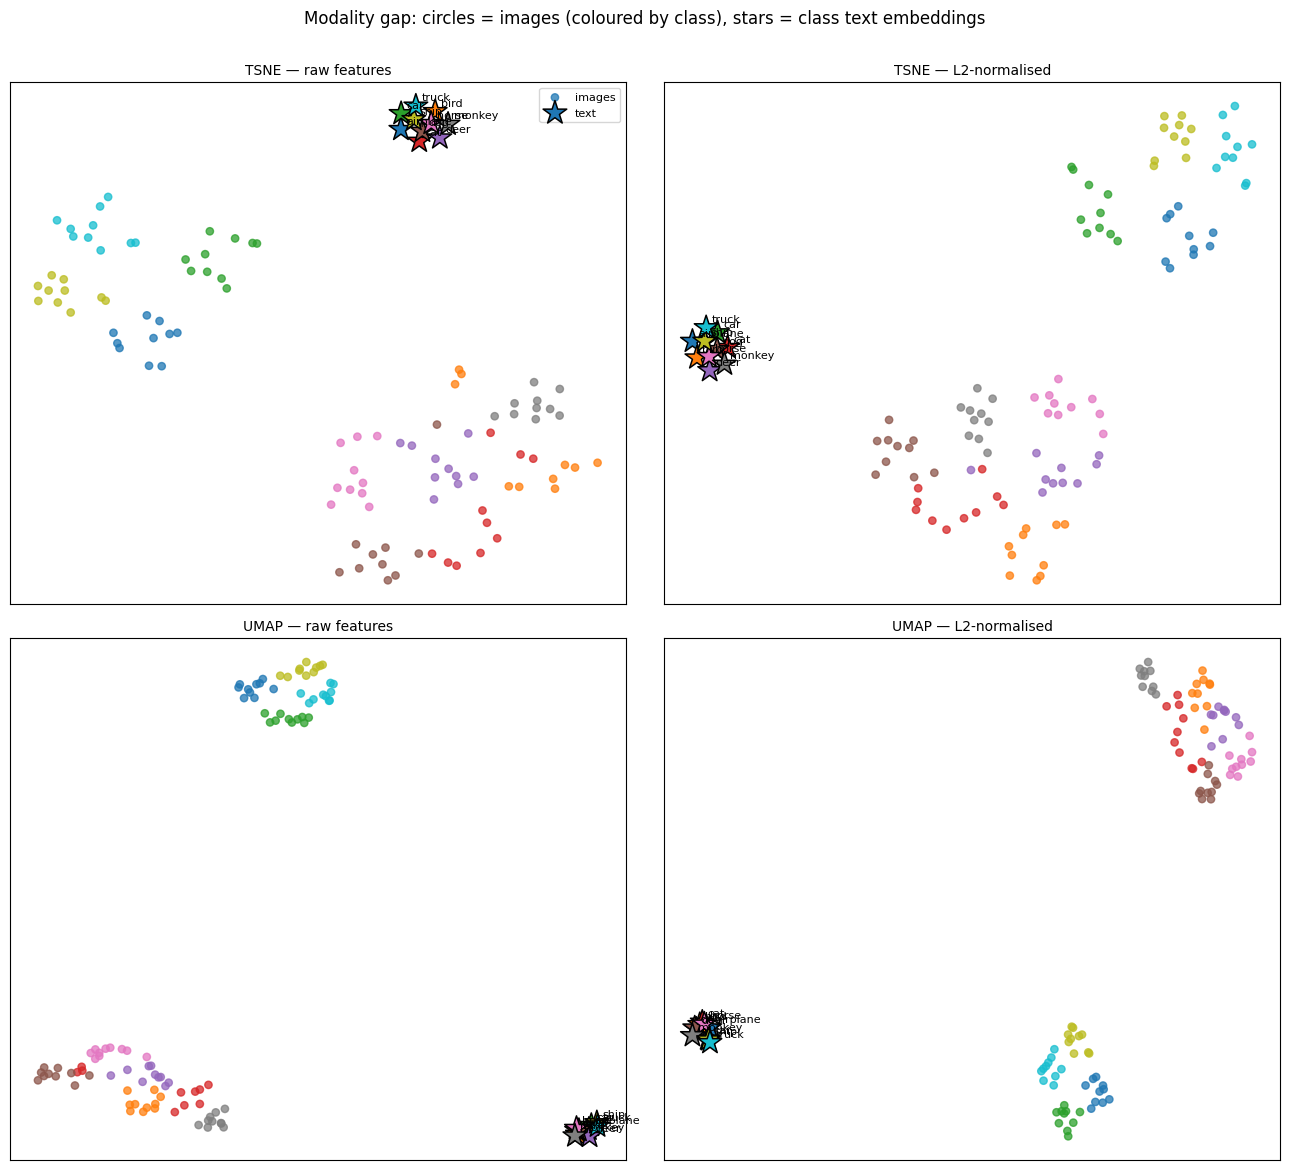

In [14]:
from sklearn.manifold import TSNE
try:
    import umap
    HAVE_UMAP = True
except Exception as e:
    HAVE_UMAP = False
    print("UMAP unavailable (%s) — falling back to t-SNE only." % e)


def project_and_plot(img, txt, labels, normalize, ax, method="tsne", title=""):
    if normalize:
        img = F.normalize(img, dim=-1)
        txt = F.normalize(txt, dim=-1)
    X = torch.cat([img, txt]).numpy()

    if method == "tsne":
        # perplexity must stay below the sample count
        proj = TSNE(n_components=2, perplexity=15, init="pca",
                    random_state=SEED).fit_transform(X)
    else:
        proj = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                         random_state=SEED).fit_transform(X)

    n_img = len(img)
    cmap = plt.get_cmap("tab10")
    ax.scatter(proj[:n_img, 0], proj[:n_img, 1], c=[cmap(l) for l in labels.numpy()],
               s=28, alpha=0.75, label="images")
    ax.scatter(proj[n_img:, 0], proj[n_img:, 1], c=[cmap(i) for i in range(len(CLASSES))],
               s=320, marker="*", edgecolors="black", linewidths=1.1, label="text")
    for i, c in enumerate(CLASSES):
        ax.annotate(c, (proj[n_img + i, 0], proj[n_img + i, 1]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])


methods = ["tsne"] + (["umap"] if HAVE_UMAP else [])
fig, axes = plt.subplots(len(methods), 2, figsize=(13, 5.8 * len(methods)),
                         squeeze=False)
for r, m in enumerate(methods):
    for c, norm in enumerate([False, True]):
        project_and_plot(sample_img_feats, sample_txt_feats, sample_labels,
                         normalize=norm, ax=axes[r][c], method=m,
                         title="%s — %s" % (m.upper(),
                                            "L2-normalised" if norm else "raw features"))
axes[0][0].legend(loc="best", fontsize=8)
fig.suptitle("Modality gap: circles = images (coloured by class), stars = class text embeddings",
             y=1.005)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "modality_gap.png"), dpi=200, bbox_inches="tight")
plt.show()

## 3.3 Bridging the Modality Gap

### Fit Procrustes Rotation

In [15]:
from scipy.linalg import orthogonal_procrustes

# Pair each TRAIN image embedding with the text embedding of its true class.
txt_for_fit = text_features[best_strategy]

X_fit = F.normalize(train_feats, dim=-1)                       # (5000, 512) images
Y_fit = F.normalize(txt_for_fit, dim=-1)[train_labels]         # (5000, 512) matched text

print("Fitting Procrustes on %d paired train embeddings..." % len(X_fit))
R, scale = orthogonal_procrustes(X_fit.numpy(), Y_fit.numpy())
R = torch.from_numpy(R).float()

print("R shape:", tuple(R.shape))
print("Orthogonality check ||R^T R - I||_F = %.6f" %
      (R.T @ R - torch.eye(R.shape[0])).norm().item())
print("Residual before: %.4f" % (X_fit - Y_fit).norm().item())
print("Residual after:  %.4f" % (X_fit @ R - Y_fit).norm().item())

Fitting Procrustes on 5000 paired train embeddings...
R shape: (512, 512)
Orthogonality check ||R^T R - I||_F = 0.000026
Residual before: 85.7814
Residual after:  37.0721


### Apply Rotation and Re-measure Gap

In [16]:
# Rotate the TEST image embeddings into the text space.
test_norm = F.normalize(test_feats, dim=-1)
test_aligned = F.normalize(test_norm @ R, dim=-1)

sample_aligned = test_aligned[sample_idx]
txt_norm = F.normalize(txt_for_fit, dim=-1)

print("Gap metrics BEFORE alignment")
for k, v in gap_metrics(F.normalize(sample_img_feats, dim=-1), txt_norm, False).items():
    print("   %-24s %8.4f" % (k, v))

print("\nGap metrics AFTER alignment")
for k, v in gap_metrics(sample_aligned, txt_norm, False).items():
    print("   %-24s %8.4f" % (k, v))

Gap metrics BEFORE alignment
   centroid_distance          1.0416
   centroid_cosine            0.2687
   mean_within_image_cos      0.6072
   mean_cross_modal_cos       0.1953

Gap metrics AFTER alignment
   centroid_distance          0.1592
   centroid_cosine            0.9977
   mean_within_image_cos      0.6072
   mean_cross_modal_cos       0.7251


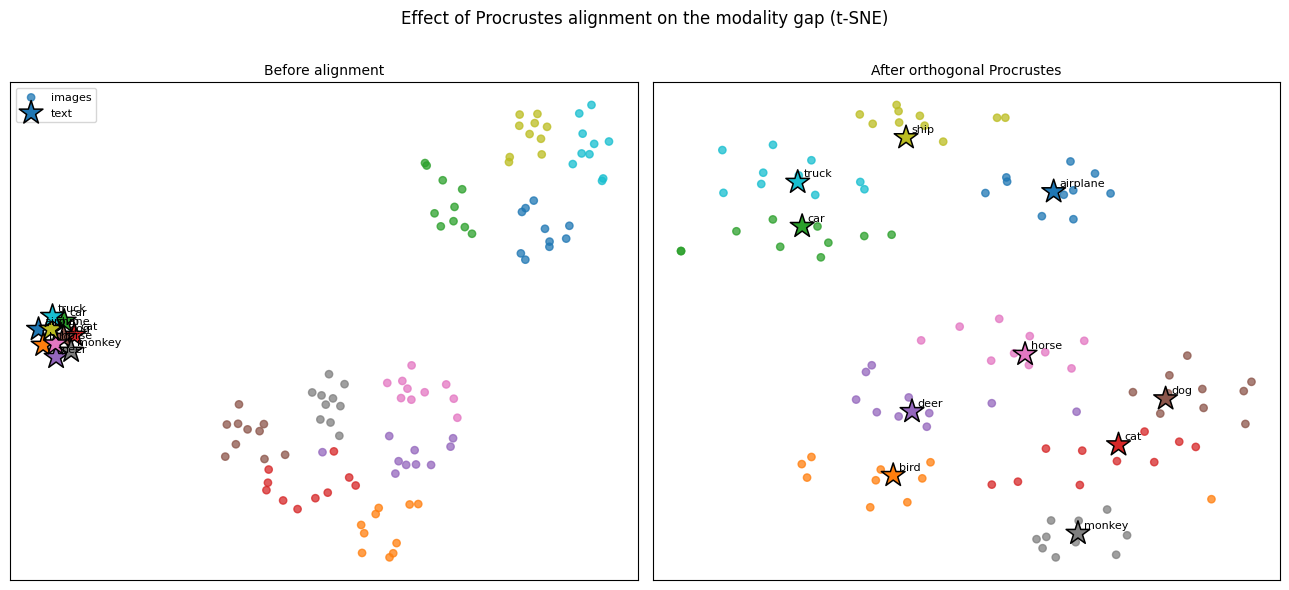

In [17]:
# Visualise the aligned embeddings alongside the originals.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
project_and_plot(F.normalize(sample_img_feats, dim=-1), txt_norm, sample_labels,
                 normalize=False, ax=axes[0], method="tsne",
                 title="Before alignment")
project_and_plot(sample_aligned, txt_norm, sample_labels,
                 normalize=False, ax=axes[1], method="tsne",
                 title="After orthogonal Procrustes")
axes[0].legend(loc="best", fontsize=8)
fig.suptitle("Effect of Procrustes alignment on the modality gap (t-SNE)", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "procrustes_alignment.png"), dpi=200,
            bbox_inches="tight")
plt.show()

### Recompute Accuracy

In [18]:
aligned_preds, _ = zero_shot_predict(test_aligned, txt_for_fit)
aligned_acc = top1_accuracy(aligned_preds, test_labels)
baseline_acc = results[best_strategy]

print("Zero-shot top-1 on the full test set (%s prompts)\n" % best_strategy)
print("  Before alignment: %6.2f%%" % (100 * baseline_acc))
print("  After Procrustes: %6.2f%%" % (100 * aligned_acc))
print("  Delta:            %+6.2f pp" % (100 * (aligned_acc - baseline_acc)))

results["E. Procrustes-aligned"] = aligned_acc

# Also evaluate every prompting strategy under the alignment, for completeness.
print("\nAll strategies, aligned vs unaligned:\n")
print("%-22s %9s %9s" % ("Strategy", "Before", "After"))
print("-" * 42)
for name, txt in text_features.items():
    p_before, _ = zero_shot_predict(test_feats, txt)
    p_after, _ = zero_shot_predict(test_aligned, txt)
    print("%-22s %8.2f%% %8.2f%%" % (name,
                                     100 * top1_accuracy(p_before, test_labels),
                                     100 * top1_accuracy(p_after, test_labels)))

Zero-shot top-1 on the full test set (B. photo prompt prompts)

  Before alignment:  97.31%
  After Procrustes:  97.83%
  Delta:             +0.51 pp

All strategies, aligned vs unaligned:

Strategy                  Before     After
------------------------------------------
A. plain label            96.25%    97.12%
B. photo prompt           97.31%    97.83%
C. descriptive            92.76%    89.51%
D. prompt ensemble        96.86%    97.81%


## Results Summary

In [19]:
summary = {
    "model": MODEL_NAME,
    "dataset": "STL-10 test split",
    "n_test_images": int(len(test_labels)),
    "zero_shot_accuracy": {k: round(100 * v, 2) for k, v in results.items()},
    "per_class_accuracy_best_strategy": {k: round(100 * v, 2) for k, v in per_class.items()},
    "best_strategy": best_strategy,
    "gap_before": gap_metrics(F.normalize(sample_img_feats, dim=-1), txt_norm, False),
    "gap_after": gap_metrics(sample_aligned, txt_norm, False),
}

with open(RESULTS_PATH, "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 46)
print("TASK 3 SUMMARY")
print("=" * 46)
print("Model: %s   |   Test images: %d\n" % (MODEL_NAME, len(test_labels)))
print("%-24s %s" % ("Strategy", "Top-1"))
print("-" * 34)
for k, v in results.items():
    print("%-24s %6.2f%%" % (k, 100 * v))
print("\nFigures written to %s/" % FIG_DIR)
print("Metrics written to %s" % RESULTS_PATH)

TASK 3 SUMMARY
Model: ViT-B/32   |   Test images: 8000

Strategy                 Top-1
----------------------------------
A. plain label            96.25%
B. photo prompt           97.31%
C. descriptive            92.76%
D. prompt ensemble        96.86%
E. Procrustes-aligned     97.83%

Figures written to ./figures/
Metrics written to task3_results.json


### LaTeX Table

In [20]:
rows = "\n".join("%s & %.2f \\\\" % (k.split(". ", 1)[-1].replace("_", " "), 100 * v)
                 for k, v in results.items())

print(r"""\begin{table}[h]
\centering
\caption{Zero-shot top-1 accuracy on the full STL-10 test set (8{,}000 images) using CLIP %s.}
\label{tab:clip-zeroshot}
\begin{tabular}{lc}
\toprule
Strategy & Top-1 (\%%) \\
\midrule
%s
\bottomrule
\end{tabular}
\end{table}""" % (MODEL_NAME.replace("/", "/"), rows))

\begin{table}[h]
\centering
\caption{Zero-shot top-1 accuracy on the full STL-10 test set (8{,}000 images) using CLIP ViT-B/32.}
\label{tab:clip-zeroshot}
\begin{tabular}{lc}
\toprule
Strategy & Top-1 (\%) \\
\midrule
plain label & 96.25 \\
photo prompt & 97.31 \\
descriptive & 92.76 \\
prompt ensemble & 96.86 \\
Procrustes-aligned & 97.83 \\
\bottomrule
\end{tabular}
\end{table}


## Environment Versions

In [21]:
import torchvision
print("torch       ", torch.__version__)
print("torchvision ", torchvision.__version__)
print("numpy       ", np.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)
import scipy; print("scipy       ", scipy.__version__)
if HAVE_UMAP:
    print("umap-learn  ", umap.__version__)
print("device      ", DEVICE)

torch        2.11.0+cu128
torchvision  0.26.0+cu128
numpy        2.1.3
scikit-learn 1.6.1
scipy        1.16.3
umap-learn   0.5.12
device       cuda
